# Phase 4: Real Data Integration & Analysis

This notebook explores **real forex data** downloaded from Yahoo Finance and compares it with our synthetic data. The goal is to understand how real markets differ from our simulations and recalibrate our strategy accordingly.

## Why Real Data Matters

Our synthetic data was essentially a **random walk in a box** - prices bounced around randomly with mean reversion. Real markets are fundamentally different:

1. **Multi-month trends**: USD/JPY went from 115 to 150+ during 2022-2023 Fed rate hikes
2. **Volatility clustering**: Calm periods followed by storms (carry trade unwinding events)
3. **Fat tails**: Real returns have more extreme moves than a normal distribution
4. **Regime changes**: Rate cycles create/destroy carry opportunities over time

In [1]:
import sys
from pathlib import Path

# Add project root to path
sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.loader import HistoricalDataLoader
from src.data.preprocessor import clean_data, validate_data, compare_synthetic_vs_real
from src.data.generator import SyntheticDataGenerator
from src.strategy.carry_trade import CarryTradeStrategy
from src.backtest.engine import BacktestEngine
from src.config.settings import StrategyConfig

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Setup complete!")

Setup complete!


## 1. Load Real Forex Data

The `HistoricalDataLoader` downloads data from Yahoo Finance and caches it locally as Parquet files. First download takes a few seconds; subsequent runs load from cache instantly.

In [2]:
loader = HistoricalDataLoader(cache_dir="../../data/cache")

# Load daily data (longer history available)
pairs = ["USD/JPY", "AUD/JPY", "EUR/USD"]
real_data_daily = {}

for pair in pairs:
    df = loader.load_pair(pair, start="2021-01-01", end="2024-12-31", interval="1d")
    if len(df) > 0:
        real_data_daily[pair] = clean_data(df)
        print(f"{pair}: {len(real_data_daily[pair])} daily bars")
        print(f"  Date range: {real_data_daily[pair]['timestamp'].iloc[0].date()} to {real_data_daily[pair]['timestamp'].iloc[-1].date()}")

USD/JPY: 1042 daily bars
  Date range: 2021-01-01 to 2024-12-30
AUD/JPY: 1042 daily bars
  Date range: 2021-01-01 to 2024-12-30
EUR/USD: 1042 daily bars
  Date range: 2021-01-01 to 2024-12-30


In [3]:
# Also load hourly data (limited to ~730 days back from today)
real_data_hourly = {}

for pair in pairs:
    df = loader.load_pair(pair, start="2024-06-01", end="2025-12-31", interval="1h")
    if len(df) > 0:
        real_data_hourly[pair] = clean_data(df)
        print(f"{pair}: {len(real_data_hourly[pair])} hourly bars")

USD/JPY: 9655 hourly bars
AUD/JPY: 9715 hourly bars
EUR/USD: 9704 hourly bars


## 2. Real Price Charts

Let's visualize the actual price movements. Notice how different this looks from our synthetic data - real markets have **persistent trends** driven by macroeconomic factors.

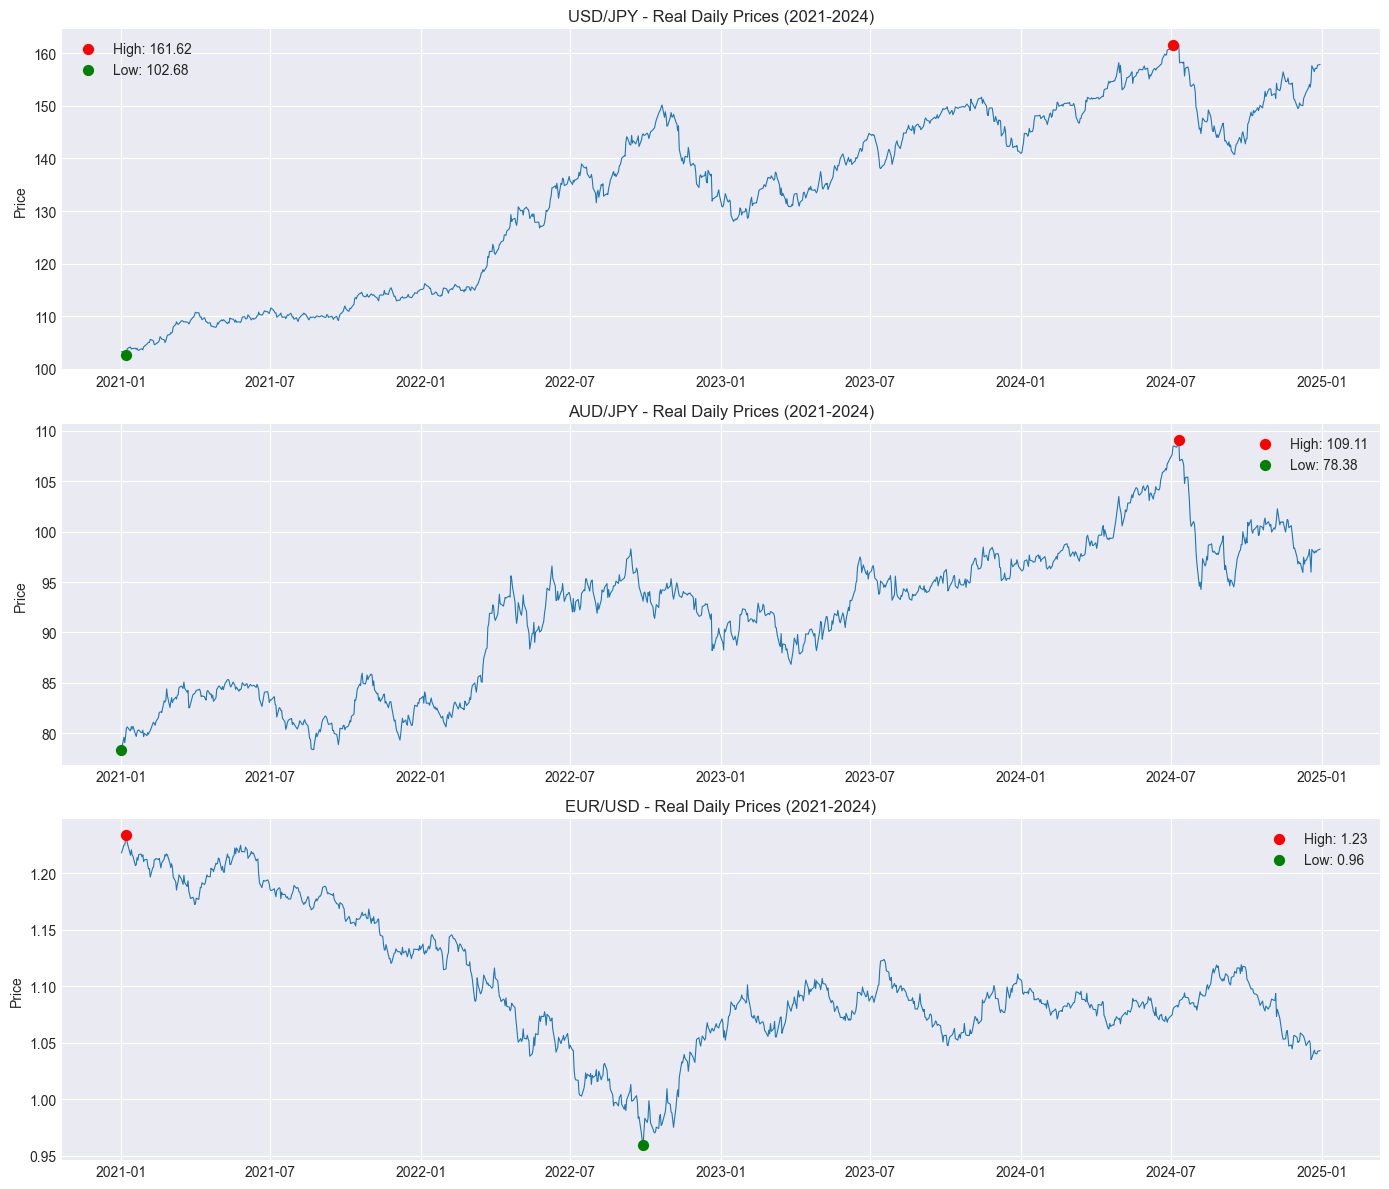

In [4]:
fig, axes = plt.subplots(len(real_data_daily), 1, figsize=(14, 4 * len(real_data_daily)))

for ax, (pair, df) in zip(axes, real_data_daily.items()):
    ax.plot(df['timestamp'], df['close'], linewidth=0.8)
    ax.set_title(f"{pair} - Real Daily Prices (2021-2024)")
    ax.set_ylabel("Price")
    
    # Add annotations for major moves
    max_idx = df['close'].idxmax()
    min_idx = df['close'].idxmin()
    ax.scatter(df.loc[max_idx, 'timestamp'], df.loc[max_idx, 'close'], color='red', s=50, zorder=5, label=f"High: {df.loc[max_idx, 'close']:.2f}")
    ax.scatter(df.loc[min_idx, 'timestamp'], df.loc[min_idx, 'close'], color='green', s=50, zorder=5, label=f"Low: {df.loc[min_idx, 'close']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

### What We See

- **USD/JPY**: Massive rally from ~104 to ~161 as the Fed hiked rates while BOJ held at zero
- **AUD/JPY**: Similar pattern but with more volatility (commodity currency + carry)
- **EUR/USD**: Weakened as US rates rose faster than ECB rates

These are **macro trends** that synthetic random walks cannot capture.

## 3. Data Quality Validation

Before backtesting, we check the data for issues:
- **Gaps**: Missing bars (holidays, data outages)
- **Outliers**: Extreme prices that might be data errors
- **Duplicates**: Repeated timestamps
- **Completeness**: What % of expected bars do we have?

In [5]:
print("Data Quality Report")
print("=" * 60)

for pair, df in real_data_daily.items():
    report = validate_data(df, pair, freq_hours=24)
    status = "PASS" if report.passed else "FAIL"
    print(f"\n{pair} [{status}]")
    print(f"  Rows: {report.total_rows}")
    print(f"  Expected bars: ~{report.expected_bars}")
    print(f"  Completeness: {report.completeness_pct}%")
    print(f"  Duplicates: {report.duplicate_timestamps}")
    print(f"  Outliers (>5 std): {report.outlier_bars}")
    print(f"  Weekend bars removed: {report.weekend_bars_removed}")

Data Quality Report

USD/JPY [PASS]
  Rows: 1042
  Expected bars: ~1042
  Completeness: 100.0%
  Duplicates: 0
  Outliers (>5 std): 2
  Weekend bars removed: 0

AUD/JPY [PASS]
  Rows: 1042
  Expected bars: ~1042
  Completeness: 100.0%
  Duplicates: 0
  Outliers (>5 std): 1
  Weekend bars removed: 0

EUR/USD [PASS]
  Rows: 1042
  Expected bars: ~1042
  Completeness: 100.0%
  Duplicates: 0
  Outliers (>5 std): 0
  Weekend bars removed: 0


## 4. Synthetic vs Real Comparison

How realistic was our synthetic data? Let's compare key statistics.

In [6]:
# Generate synthetic data for comparison
gen = SyntheticDataGenerator(seed=42)
syn_data = gen.generate_all_pairs(days=365)

print("Synthetic vs Real Data Comparison")
print("=" * 60)

for pair in pairs:
    if pair not in real_data_daily or pair not in syn_data:
        continue
        
    comp = compare_synthetic_vs_real(syn_data[pair], real_data_daily[pair], pair)
    
    print(f"\n{pair}:")
    print(f"  {'Metric':<20} {'Synthetic':>12} {'Real':>12}")
    print(f"  {'-'*44}")
    for metric, syn_val, real_val in zip(comp['metric'], comp['synthetic'], comp['real']):
        print(f"  {metric:<20} {str(syn_val):>12} {str(real_val):>12}")

Synthetic vs Real Data Comparison

USD/JPY:
  Metric                  Synthetic         Real
  --------------------------------------------
  bars                         6264         1042
  price_mean                 148.33       133.29
  price_std                     2.3        16.78
  return_mean              2.28e-05    0.0004261
  return_std               0.006993     0.005982
  return_skew                 0.006       -0.484
  return_kurtosis             0.536        3.593
  ann_vol                    0.5438       0.4652

AUD/JPY:
  Metric                  Synthetic         Real
  --------------------------------------------
  bars                         6264         1042
  price_mean                  98.39        91.68
  price_std                    2.31         7.04
  return_mean              5.68e-05    0.0002407
  return_std               0.010577     0.006844
  return_skew                 0.024       -0.219
  return_kurtosis             0.402        1.719
  ann_vol          

### Key Differences

1. **Kurtosis**: Real data has much higher kurtosis (fat tails) - more extreme moves than synthetic
2. **Skewness**: Real data often has negative skew - crashes are faster than rallies
3. **Annualized Volatility**: Can be similar, but real vol clusters (not constant)
4. **Price Range**: Real prices trended significantly; synthetic stayed in a box

## 5. Returns Distribution Comparison

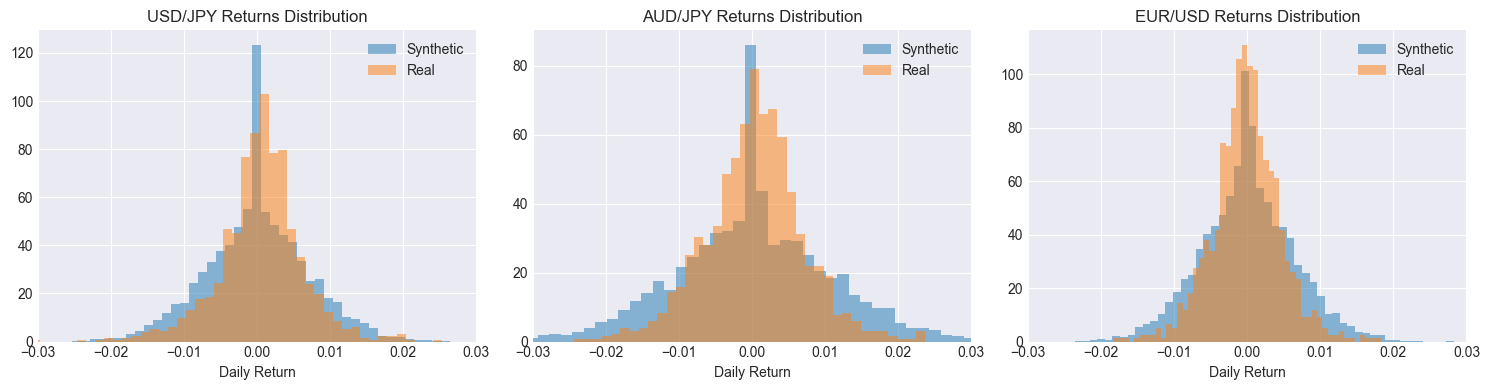

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, pair in zip(axes, pairs):
    if pair not in real_data_daily or pair not in syn_data:
        continue
    
    real_ret = real_data_daily[pair]['close'].pct_change().dropna()
    syn_ret = syn_data[pair]['close'].pct_change().dropna()
    
    ax.hist(syn_ret, bins=50, alpha=0.5, label='Synthetic', density=True)
    ax.hist(real_ret, bins=50, alpha=0.5, label='Real', density=True)
    ax.set_title(f"{pair} Returns Distribution")
    ax.set_xlabel("Daily Return")
    ax.legend()
    ax.set_xlim(-0.03, 0.03)

plt.tight_layout()
plt.show()

## 6. Backtest on Real Data

Now the moment of truth - how does our strategy perform on **actual market data**?

In [8]:
# Use hourly data for backtesting (more signals)
backtest_data = real_data_hourly if real_data_hourly else real_data_daily

# Default parameters first
strategy = CarryTradeStrategy()
engine = BacktestEngine(strategy)

print("Backtest Results (Default Parameters)")
print("=" * 60)
print(f"{'Pair':<12} {'Return':>10} {'Sharpe':>8} {'Trades':>8} {'MaxDD':>10}")
print("-" * 60)

results = {}
for pair, df in backtest_data.items():
    result = engine.run(df, pair)
    results[pair] = result
    m = result.metrics
    print(f"{pair:<12} {m.total_return:>9.2%} {m.sharpe_ratio:>8.2f} {m.total_trades:>8} {m.max_drawdown:>9.2%}")

Backtest Results (Default Parameters)
Pair             Return   Sharpe   Trades      MaxDD
------------------------------------------------------------
USD/JPY         -1.46%    -0.82       18     2.45%
AUD/JPY         -1.92%    -1.05       21     3.04%
EUR/USD          0.00%     0.00        0     0.00%


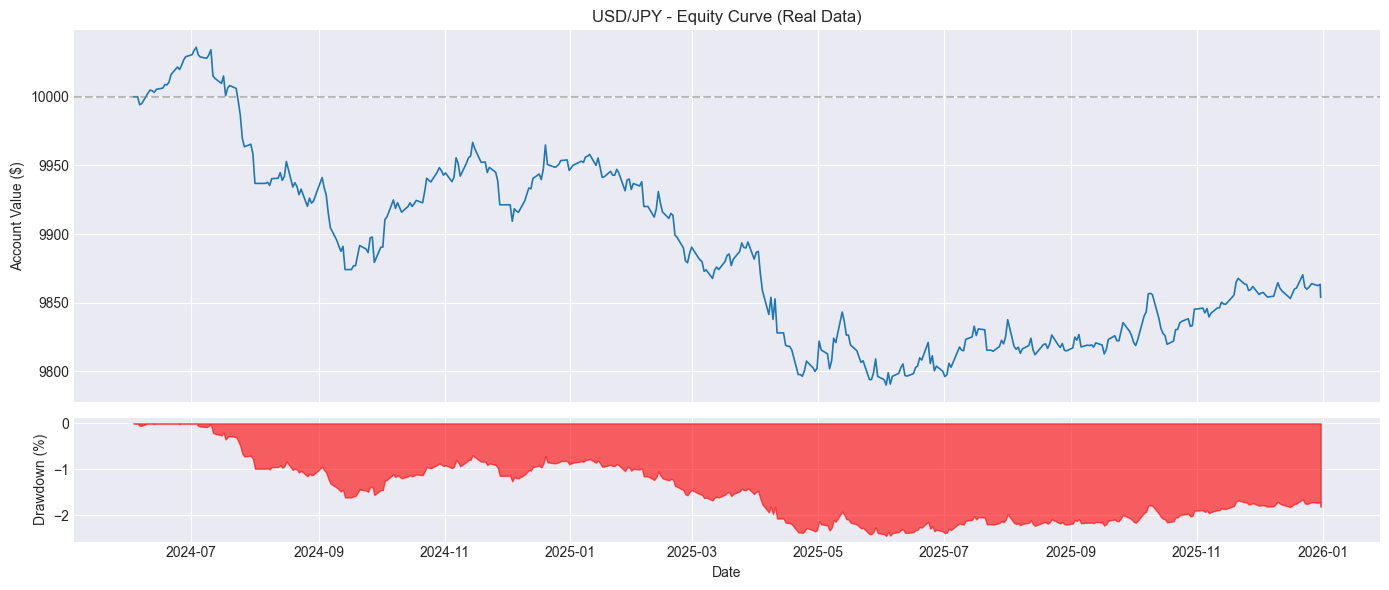

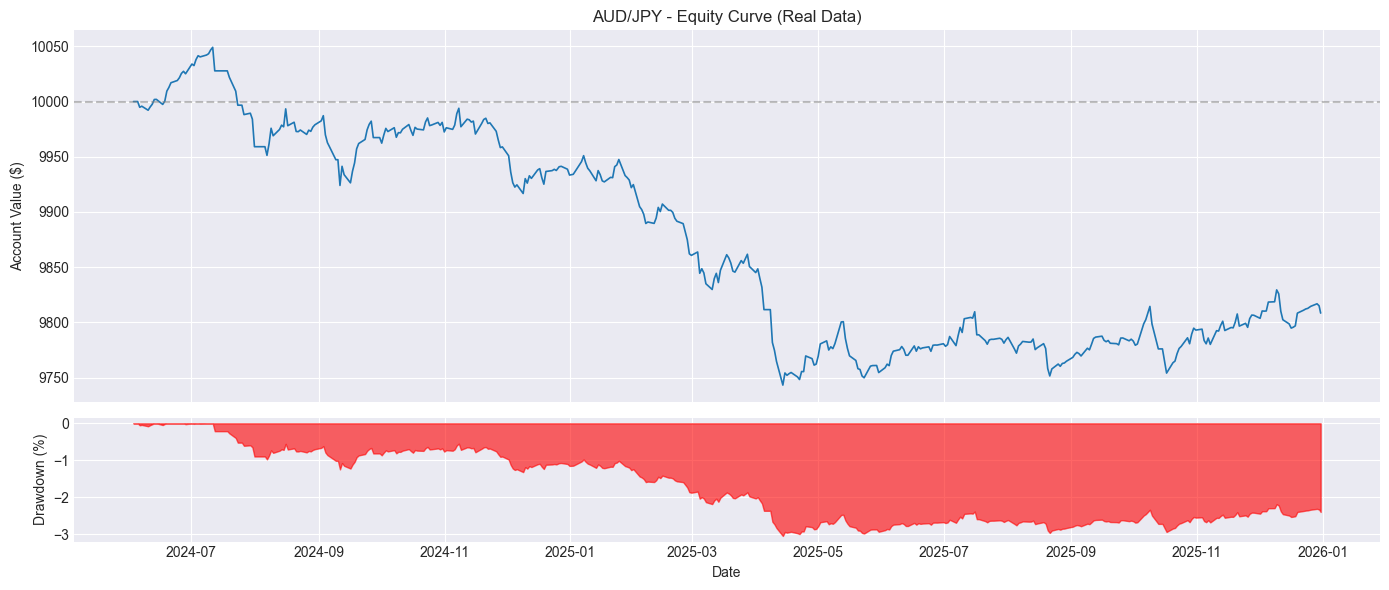

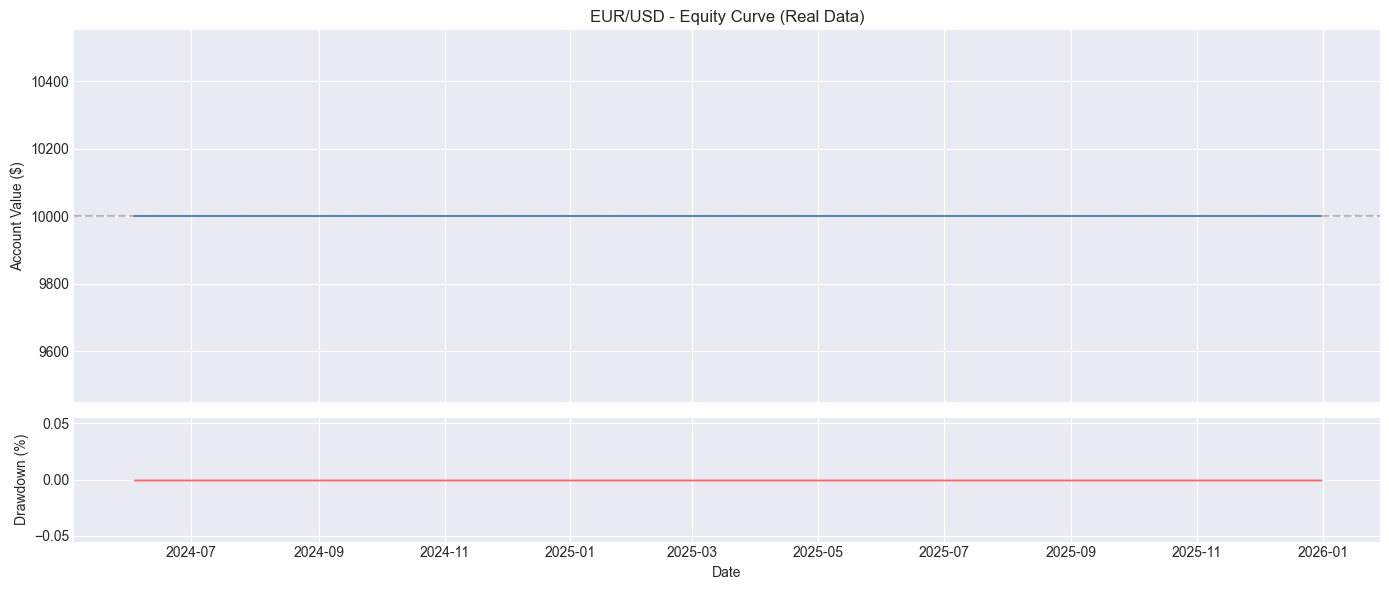

In [9]:
# Plot equity curves inline (simplified version)
for pair, result in results.items():
    eq = result.equity_df
    if len(eq) == 0:
        continue
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), height_ratios=[3, 1], sharex=True)
    
    ax1.plot(eq["timestamp"], eq["equity"], linewidth=1.2)
    ax1.axhline(eq["equity"].iloc[0], color="gray", linestyle="--", alpha=0.5)
    ax1.set_title(f"{pair} - Equity Curve (Real Data)")
    ax1.set_ylabel("Account Value ($)")
    
    ax2.fill_between(eq["timestamp"], 0, -eq["drawdown"] * 100, color="red", alpha=0.6)
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    
    plt.tight_layout()
    plt.show()

## 7. Parameter Re-Optimization

Parameters optimized on synthetic data may not work on real data. Let's re-optimize.

In [10]:
from src.optimization.grid_search import GridSearchOptimizer

# Pick the pair with most data
best_pair = max(backtest_data.keys(), key=lambda p: len(backtest_data[p]))
opt_df = backtest_data[best_pair]

print(f"Optimizing on {best_pair} ({len(opt_df)} bars)...")

param_grid = {
    "stop_loss_pct": [0.02, 0.04, 0.06, 0.08],
    "trend_filter_period": [20, 50, 100],
    "position_size_pct": [0.05, 0.10, 0.15],
}

optimizer = GridSearchOptimizer(opt_df, best_pair)
opt_results = optimizer.run(param_grid)

Optimizing on AUD/JPY (9715 bars)...


In [11]:
print(f"\nTop 10 Parameter Combinations (Real Data)")
print("=" * 70)
print(f"{'#':>3} {'Sharpe':>8} {'Return':>10} {'MaxDD':>10} {'Trades':>8} {'SL':>6} {'SMA':>5} {'Size':>6}")
print("-" * 70)

for i, r in enumerate(opt_results[:10]):
    print(f"{i+1:>3} {r.sharpe:>8.2f} {r.total_return:>9.2%} {r.max_drawdown:>9.2%} "
          f"{r.total_trades:>8} {r.params['stop_loss_pct']:>5.0%} "
          f"{r.params['trend_filter_period']:>5} {r.params['position_size_pct']:>5.0%}")


Top 10 Parameter Combinations (Real Data)
  #   Sharpe     Return      MaxDD   Trades     SL   SMA   Size
----------------------------------------------------------------------
  1    -0.03    -0.10%     3.18%        9    8%    50   15%
  2    -0.08    -0.25%     3.20%       11    6%    50   15%
  3    -0.11    -0.34%     3.38%        9    8%    20   15%
  4    -0.11    -0.32%     2.97%        8    8%   100   15%
  5    -0.15    -0.44%     3.48%       14    4%    20   15%
  6    -0.15    -0.41%     3.06%       10    4%   100   15%
  7    -0.19    -0.36%     2.29%        9    8%    50   10%
  8    -0.23    -0.62%     3.27%        9    6%   100   15%
  9    -0.26    -0.47%     2.12%        8    8%   100   10%
 10    -0.26    -0.52%     2.36%        9    8%    20   10%


In [12]:
# Test best params on all pairs
if opt_results:
    best = opt_results[0]
    print(f"\nBest Parameters: {best.params}")
    print("\nBacktest with Best Parameters:")
    print("=" * 60)
    
    best_config = StrategyConfig(**best.params)
    best_strategy = CarryTradeStrategy(best_config)
    best_engine = BacktestEngine(best_strategy, best_config)
    
    print(f"{'Pair':<12} {'Return':>10} {'Sharpe':>8} {'Trades':>8} {'MaxDD':>10}")
    print("-" * 60)
    
    for pair, df in backtest_data.items():
        result = best_engine.run(df, pair)
        m = result.metrics
        print(f"{pair:<12} {m.total_return:>9.2%} {m.sharpe_ratio:>8.2f} {m.total_trades:>8} {m.max_drawdown:>9.2%}")


Best Parameters: {'stop_loss_pct': 0.08, 'trend_filter_period': 50, 'position_size_pct': 0.15}

Backtest with Best Parameters:
Pair             Return   Sharpe   Trades      MaxDD
------------------------------------------------------------
USD/JPY         -0.84%    -0.31        6     2.62%
AUD/JPY         -0.10%    -0.03        9     3.18%
EUR/USD          0.00%     0.00        0     0.00%


## 8. Key Insights from Real Data

### What We Learned

1. **Real markets trend**: Our synthetic data missed the massive USD/JPY rally driven by Fed rate hikes
2. **Stop losses matter more**: Tight stops get whipsawed in real volatility clusters
3. **Carry works over long periods**: The rate differential compounds over time
4. **Regime changes are real**: 2022-2023 was a rare period where carry trades worked exceptionally well

### For Phase 5

We'll address these findings by implementing:
- **Dynamic position sizing** (Kelly Criterion) to adjust for varying volatility
- **ATR-based stop losses** that adapt to current market conditions
- **Circuit breakers** to limit damage during volatility spikes
- **VaR analysis** to quantify tail risk

In [13]:
print("Phase 4 complete!")
print("\nNext: Phase 5 - Advanced Risk Management")

Phase 4 complete!

Next: Phase 5 - Advanced Risk Management
